# TŘETÍ PREDIKCE - RUL

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Načtení datasetu
df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp")
# Kontrola dat
df.head()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
78843,2022-01-01,4,49.3,2.28,4.61,89.27,17.8,1,73,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1296.0
105124,2022-01-01,5,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1818.0
131405,2022-01-01,6,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1110.0
26281,2022-01-01,2,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1242.0


In [115]:
# Namapování názvů linek vůči ID
machine_map = {
    1: "L1 - Řezací stanice",
    2: "L1 - Lis",
    3: "L1 - Montážní stanice",
    4: "L1 - Testovací stanice",
    5: "L2 - Řezací stanice",
    6: "L2 - Lis",
    7: "L2 - Montážní stanice",
    8: "L2 - Testovací stanice",
    9: "L3 - Řezací stanice",
    10: "L3 - Lis",
    11: "L3 - Montážní stanice",
    12: "L3 - Testovací stanice"
}

In [116]:
df.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                        288
rolling_temp_mean_24h                   276
rolling_temp_std_24h                    276
rolling_vibration_mean_24h              276
rolling_vibration_std_24h               276
rolling_pressure_mean_24h               276
rolling_pressure_std_24h                276
running_ratio_24h                       276
hours_since_last_failure              15939
failure_count_last_7d           

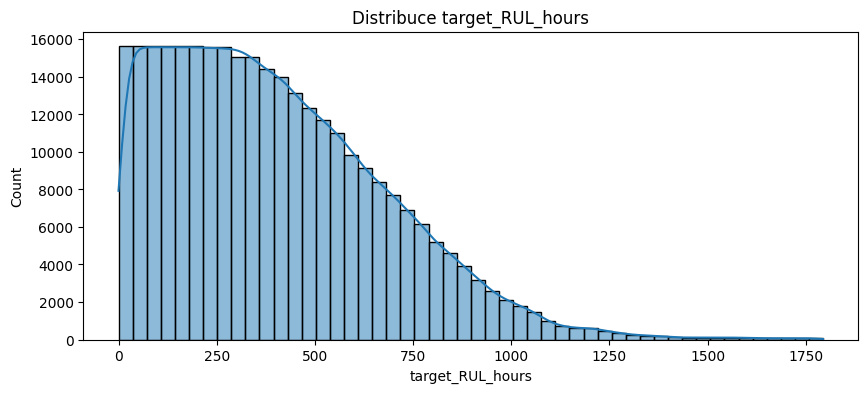

In [117]:
plt.figure(figsize=(10, 4))
sns.histplot(df_rul["target_RUL_hours"], bins=50, kde=True)
plt.title("Distribuce target_RUL_hours")
plt.show()

In [118]:
# Jen řádky, kde není target sloupec NaN
df_rul = df.dropna(subset=["target_RUL_hours"]).copy()

# stejné doplnění jako u předchozí predikce
df_rul["hours_since_last_failure"] = df_rul["hours_since_last_failure"].fillna(
    df_rul["machine_age_hours"]
)

features = df_rul.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",  # chceme vynechat
    "produced_units",
    "defective_units"
]).tolist()

df_rul[["target_RUL_hours"]].describe()

,target_RUL_hours
count,310325.000000
mean,402.158389
std,280.188659
min,0.000000
25%,178.000000
50%,359.000000
75%,578.000000
max,1818.000000


In [119]:
df_rul.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                        288
rolling_temp_mean_24h                   276
rolling_temp_std_24h                    276
rolling_vibration_mean_24h              276
rolling_vibration_std_24h               276
rolling_pressure_mean_24h               276
rolling_pressure_std_24h                276
running_ratio_24h                       276
hours_since_last_failure                  0
failure_count_last_7d           

In [120]:
df_rul = df_rul.dropna(subset=features)
df_rul = df_rul.reset_index(drop=True)

In [121]:
df_rul.shape

(310037, 27)

In [122]:
df_rul.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                          0
rolling_temp_mean_24h                     0
rolling_temp_std_24h                      0
rolling_vibration_mean_24h                0
rolling_vibration_std_24h                 0
rolling_pressure_mean_24h                 0
rolling_pressure_std_24h                  0
running_ratio_24h                         0
hours_since_last_failure                  0
failure_count_last_7d           

In [123]:
# Rozdělení datasetu dle času (model se učí na starých datech a testuje na nových)
# Seřazení dat
df_rul = df_rul.sort_values("timestamp")

# Split podle času
split_time = df_rul["timestamp"].quantile(0.8)

train = df_rul[df_rul["timestamp"] < split_time]
test = df_rul[df_rul["timestamp"] >= split_time]

# Vytvoření X a y
X_train = train[features]
y_train = train["target_RUL_hours"]

X_test = test[features]
y_test = test["target_RUL_hours"]

In [124]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [125]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.4f}")


In [126]:
model_dummy = DummyRegressor(strategy="median")
model_dummy.fit(X_train, y_train)

pred_dummy = model_dummy.predict(X_test)

print("=== Dummy Regressor ===")
evaluate_regression(y_test, pred_dummy)


=== Dummy Regressor ===
MAE:  210.31
RMSE: 256.89
R2:   -0.0000


In [127]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print("=== Linear Regression ===")
evaluate_regression(y_test, pred_lr)


=== Linear Regression ===
MAE:  96.44
RMSE: 119.57
R2:   0.7834


In [128]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print("=== Random Forest Regressor ===")
evaluate_regression(y_test, pred_rf)


=== Random Forest Regressor ===
MAE:  63.42
RMSE: 85.41
R2:   0.8895


In [129]:
model_hgb = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

model_hgb.fit(X_train, y_train)

pred_hgb = model_hgb.predict(X_test)

print("=== HistGradientBoostingRegressor ===")
evaluate_regression(y_test, pred_hgb)


=== HistGradientBoostingRegressor ===
MAE:  62.80
RMSE: 80.56
R2:   0.9017


In [130]:
results = pd.DataFrame([
    {
        "model": "Dummy Regressor",
        "MAE": mean_absolute_error(y_test, pred_dummy),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_dummy)),
        "R2": r2_score(y_test, pred_dummy)
    },
    {
        "model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, pred_lr),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_lr)),
        "R2": r2_score(y_test, pred_lr)
    },
    {
        "model": "Random Forest",
        "MAE": mean_absolute_error(y_test, pred_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_rf)),
        "R2": r2_score(y_test, pred_rf)
    },
    {
        "model": "HistGradientBoosting",
        "MAE": mean_absolute_error(y_test, pred_hgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_hgb)),
        "R2": r2_score(y_test, pred_hgb)
    }
])

results.sort_values("MAE")


,model,MAE,RMSE,R2
3,HistGradientBoosting,62.801738,80.557473,0.901662
2,Random Forest,63.424657,85.408980,0.889461
1,Linear Regression,96.439400,119.565840,0.783367
0,Dummy Regressor,210.305601,256.893050,-0.000033


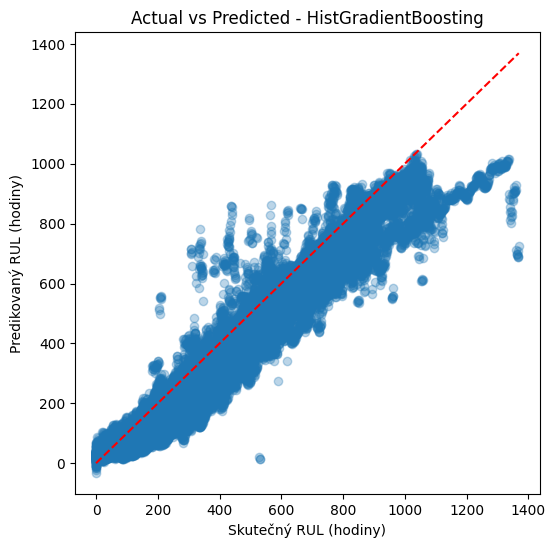

In [131]:
# Actual vs Predicted - HistGradientBoosting
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_hgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Skutečný RUL (hodiny)")
plt.ylabel("Predikovaný RUL (hodiny)")
plt.title("Actual vs Predicted - HistGradientBoosting")
plt.show()


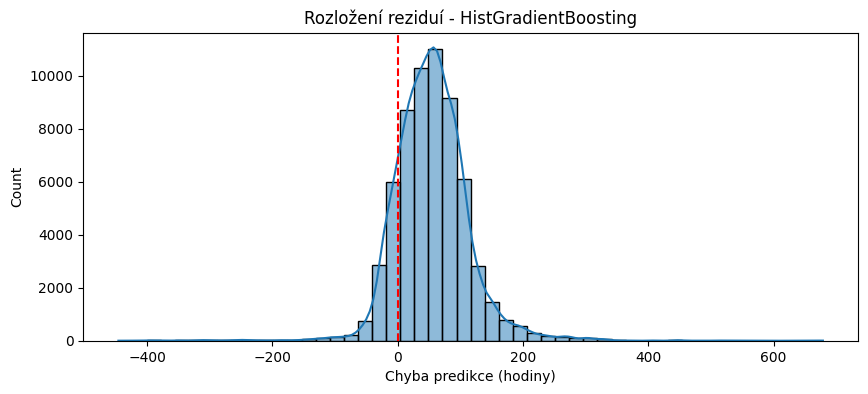

In [132]:
# Rezidua - HistGradientBoosting
residuals_hgb = y_test - pred_hgb

plt.figure(figsize=(10, 4))
sns.histplot(residuals_hgb, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Rozložení reziduí - HistGradientBoosting")
plt.xlabel("Chyba predikce (hodiny)")
plt.show()


In [133]:
# Permutation importance - HistGradientBoosting
perm_hgb = permutation_importance(
    model_hgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_hgb_df = pd.Series(
    perm_hgb.importances_mean,
    index=features
).sort_values(ascending=False)

perm_hgb_df.head(15)

rolling_vibration_mean_24h           134.116319
machine_age_hours                     46.499625
health_delta_24h                      32.826701
rolling_pressure_mean_24h             30.368808
running_ratio_24h                     16.879767
hours_since_last_failure               3.387579
operating_hours_since_maintenance      2.424885
rolling_temp_mean_24h                  1.865305
rolling_temp_std_24h                   0.706259
rolling_vibration_std_24h              0.481002
failure_count_last_30d                 0.213921
rolling_pressure_std_24h               0.024647
is_running                             0.015013
load                                   0.000118
failure_count_last_7d                  0.000000
dtype: float64

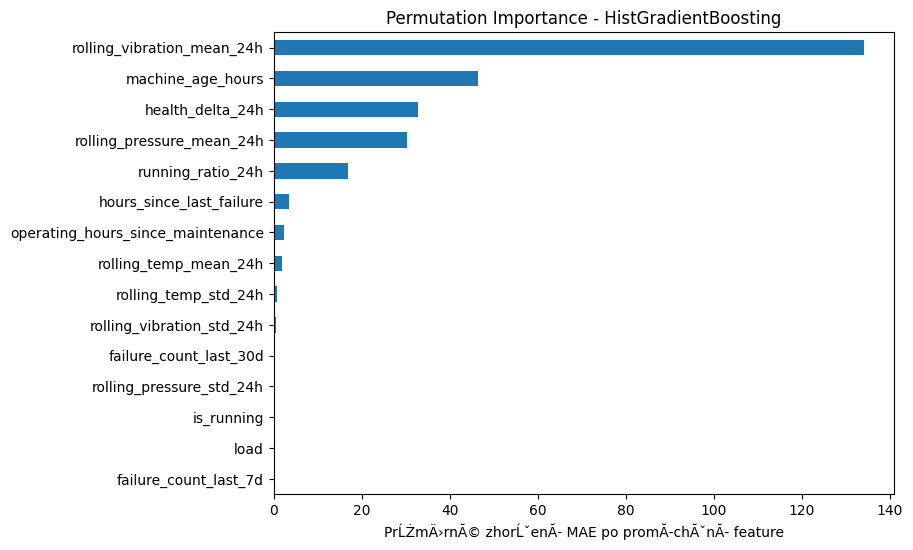

In [134]:
plt.figure(figsize=(8, 6))
perm_hgb_df.head(15).sort_values().plot(kind="barh")
plt.title("Permutation Importance - HistGradientBoosting")
plt.xlabel("PrĹŻmÄ›rnĂ© zhorĹˇenĂ­ MAE po promĂ­chĂˇnĂ­ feature")
plt.show()

## XGBoost model TEST

In [135]:
from xgboost import XGBRegressor


In [136]:
model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

print("=== XGBoost Regressor ===")
evaluate_regression(y_test, pred_xgb)


=== XGBoost Regressor ===
MAE:  61.55
RMSE: 77.69
R2:   0.9085


In [137]:
# Feature importance - XGBoost
importance_xgb = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=False)
importance_xgb.head(15)


failure_count_last_7d                0.254572
rolling_vibration_mean_24h           0.232045
rolling_pressure_mean_24h            0.173962
vibration                            0.092940
running_ratio_24h                    0.077929
machine_age_hours                    0.049718
health_delta_24h                     0.039427
hours_since_last_failure             0.028988
rolling_temp_mean_24h                0.014993
is_running                           0.008583
pressure                             0.007422
rolling_vibration_std_24h            0.004714
rolling_temp_std_24h                 0.004566
operating_hours_since_maintenance    0.003953
failure_count_last_30d               0.002419
dtype: float32

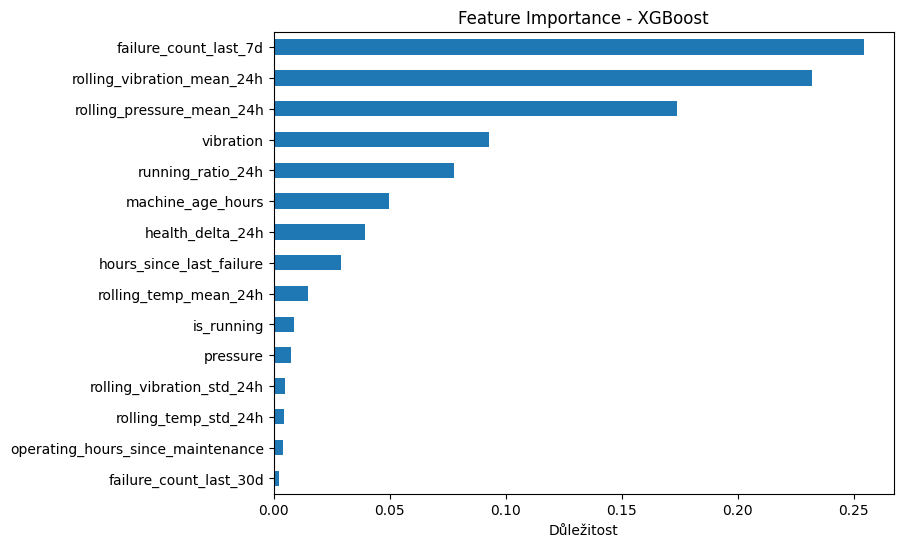

In [138]:
plt.figure(figsize=(8, 6))
importance_xgb.head(15).sort_values().plot(kind="barh")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Důležitost")
plt.show()


In [139]:
results_all = pd.DataFrame([
    {
        "model": "Dummy Regressor",
        "MAE": mean_absolute_error(y_test, pred_dummy),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_dummy)),
        "R2": r2_score(y_test, pred_dummy)
    },
    {
        "model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, pred_lr),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_lr)),
        "R2": r2_score(y_test, pred_lr)
    },
    {
        "model": "Random Forest",
        "MAE": mean_absolute_error(y_test, pred_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_rf)),
        "R2": r2_score(y_test, pred_rf)
    },
    {
        "model": "HistGradientBoosting",
        "MAE": mean_absolute_error(y_test, pred_hgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_hgb)),
        "R2": r2_score(y_test, pred_hgb)
    },
    {
        "model": "XGBoost",
        "MAE": mean_absolute_error(y_test, pred_xgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_xgb)),
        "R2": r2_score(y_test, pred_xgb)
    }
])

results_all.sort_values("MAE")


,model,MAE,RMSE,R2
4,XGBoost,61.553378,77.691540,0.908535
3,HistGradientBoosting,62.801738,80.557473,0.901662
2,Random Forest,63.424657,85.408980,0.889461
1,Linear Regression,96.439400,119.565840,0.783367
0,Dummy Regressor,210.305601,256.893050,-0.000033


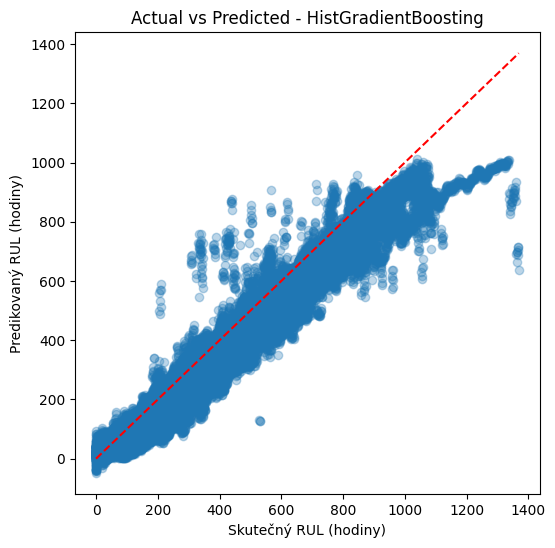

In [140]:
# Actual vs Predicted - XGBoost
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Skutečný RUL (hodiny)")
plt.ylabel("Predikovaný RUL (hodiny)")
plt.title("Actual vs Predicted - HistGradientBoosting")
plt.show()

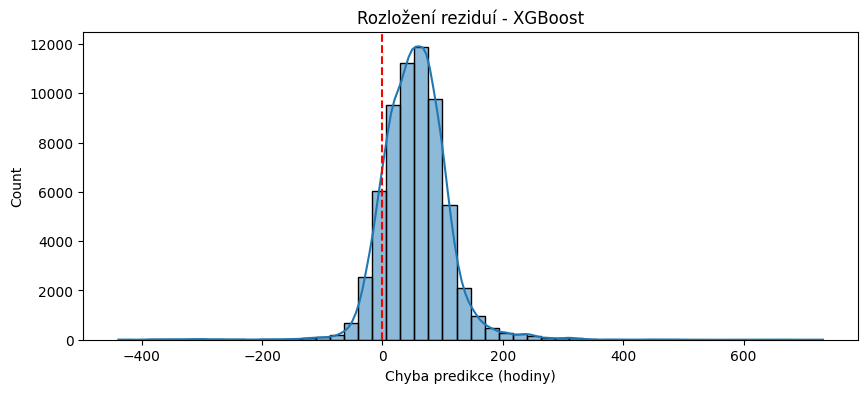

In [141]:
# Rezidua - XGBoost
residuals_xgb = y_test - pred_xgb

plt.figure(figsize=(10, 4))
sns.histplot(residuals_xgb, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Rozložení reziduí - XGBoost")
plt.xlabel("Chyba predikce (hodiny)")
plt.show()

In [142]:
# Permutation importance - XGBoost
perm_xgb = permutation_importance(
    model_xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_xgb_df = pd.Series(
    perm_xgb.importances_mean,
    index=features
).sort_values(ascending=False)

perm_xgb_df.head(15)

rolling_vibration_mean_24h           123.150639
machine_age_hours                     44.987657
health_delta_24h                      34.723776
rolling_pressure_mean_24h             27.078726
running_ratio_24h                     10.441936
rolling_temp_mean_24h                  5.574559
hours_since_last_failure               3.558751
operating_hours_since_maintenance      1.895764
rolling_temp_std_24h                   0.648318
rolling_vibration_std_24h              0.525772
is_running                             0.151386
ambient_temperature                    0.071143
pressure                               0.067929
failure_count_last_30d                 0.032690
rolling_pressure_std_24h               0.003015
dtype: float64

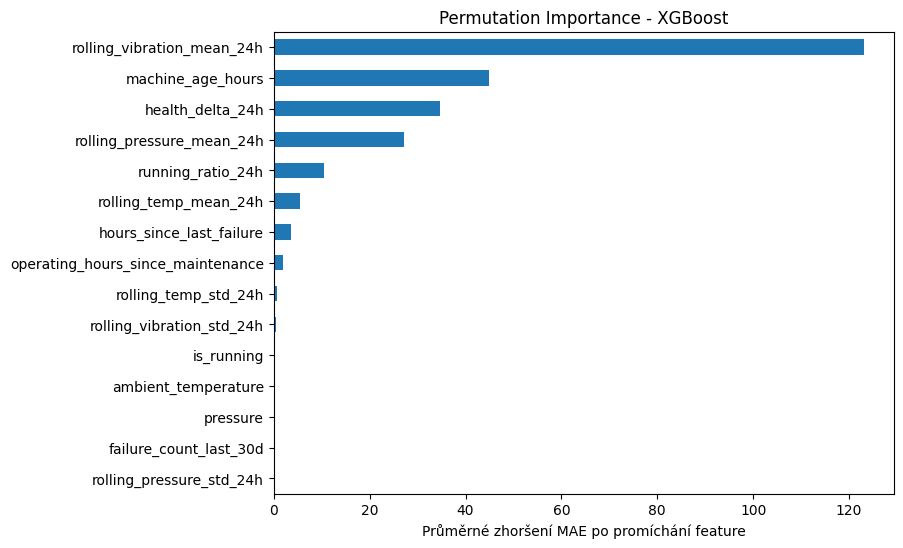

In [143]:
plt.figure(figsize=(8, 6))
perm_xgb_df.head(15).sort_values().plot(kind="barh")
plt.title("Permutation Importance - XGBoost")
plt.xlabel("Průměrné zhoršení MAE po promíchání feature")
plt.show()

## XGBoost s log1p(target_RUL_hours)

In [144]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [145]:
model_xgb_log = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_xgb_log.fit(X_train, y_train_log)

pred_xgb_log_raw = model_xgb_log.predict(X_test)
pred_xgb_log = np.expm1(pred_xgb_log_raw)

In [146]:
print("=== XGBoost Regressor (log1p target) ===")
evaluate_regression(y_test, pred_xgb_log)

=== XGBoost Regressor (log1p target) ===
MAE:  62.94
RMSE: 80.64
R2:   0.9015


In [147]:
comparison_xgb = pd.DataFrame([
    {
        "model": "XGBoost_raw",
        "MAE": mean_absolute_error(y_test, pred_xgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_xgb)),
        "R2": r2_score(y_test, pred_xgb)
    },
    {
        "model": "XGBoost_log1p",
        "MAE": mean_absolute_error(y_test, pred_xgb_log),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_xgb_log)),
        "R2": r2_score(y_test, pred_xgb_log)
    }
])

comparison_xgb.sort_values("MAE")

,model,MAE,RMSE,R2
0,XGBoost_raw,61.553378,77.691540,0.908535
1,XGBoost_log1p,62.936672,80.635318,0.901472


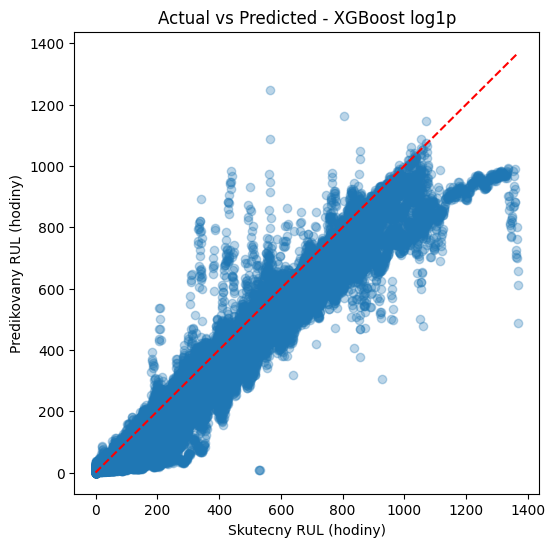

In [148]:
# Actual vs Predicted - XGBoost log1p
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_xgb_log, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Skutecny RUL (hodiny)")
plt.ylabel("Predikovany RUL (hodiny)")
plt.title("Actual vs Predicted - XGBoost log1p")
plt.show()

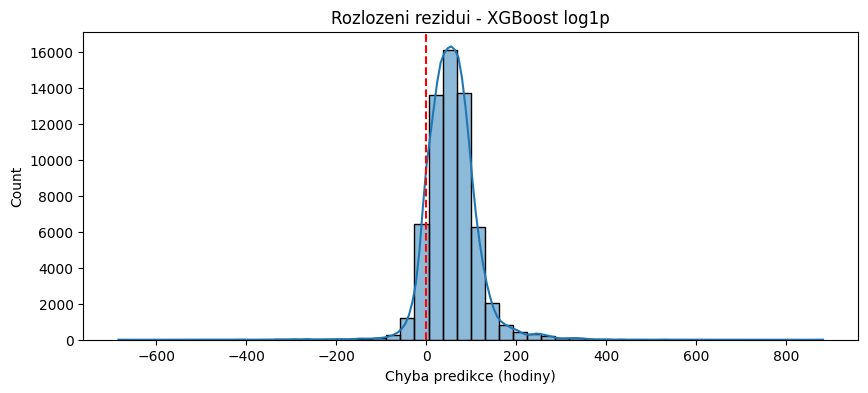

In [149]:
# Rezidua - XGBoost log1p
residuals_xgb_log = y_test - pred_xgb_log

plt.figure(figsize=(10, 4))
sns.histplot(residuals_xgb_log, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Rozlozeni rezidui - XGBoost log1p")
plt.xlabel("Chyba predikce (hodiny)")
plt.show()

## Finální predikce RUL z nejlepšího modelu

In [150]:
predictions_xgb = test.loc[X_test.index, ["timestamp", "machine_id"]].copy()
predictions_xgb["machine_name"] = predictions_xgb["machine_id"].map(machine_map)
predictions_xgb["actual_rul_hours"] = y_test.values
predictions_xgb["predicted_rul_hours_raw"] = pred_xgb
predictions_xgb["predicted_rul_hours"] = np.clip(pred_xgb, 0, None)
predictions_xgb["absolute_error_hours"] = np.abs(
    predictions_xgb["actual_rul_hours"] - predictions_xgb["predicted_rul_hours"]
)
predictions_xgb["signed_error_hours"] = (
    predictions_xgb["actual_rul_hours"] - predictions_xgb["predicted_rul_hours"]
)

predictions_xgb = predictions_xgb.sort_values(["timestamp", "machine_id"]).reset_index(drop=True)

predictions_xgb_readable = predictions_xgb[[
    "timestamp",
    "machine_id",
    "machine_name",
    "actual_rul_hours",
    "predicted_rul_hours",
    "absolute_error_hours",
    "signed_error_hours",
]].copy()

predictions_xgb_readable = predictions_xgb_readable.rename(columns={
    "timestamp": "Timestamp",
    "machine_id": "Machine ID",
    "machine_name": "Machine Name",
    "actual_rul_hours": "Actual RUL (hours)",
    "predicted_rul_hours": "Predicted RUL (hours)",
    "absolute_error_hours": "Absolute Error (hours)",
    "signed_error_hours": "Signed Error (hours)",
})

predictions_xgb_readable.head(20)

,Timestamp,Machine ID,Machine Name,Actual RUL (hours),Predicted RUL (hours),Absolute Error (hours),Signed Error (hours)
0,2024-05-12 05:00:00,1,L1 - Řezací stanice,155.0,111.683281,43.316719,43.316719
1,2024-05-12 05:00:00,2,L1 - Lis,221.0,176.229538,44.770462,44.770462
2,2024-05-12 05:00:00,3,L1 - Montážní stanice,425.0,413.788330,11.211670,11.211670
3,2024-05-12 05:00:00,4,L1 - Testovací stanice,881.0,906.267151,25.267151,-25.267151
4,2024-05-12 05:00:00,5,L2 - Řezací stanice,249.0,131.761505,117.238495,117.238495
5,2024-05-12 05:00:00,6,L2 - Lis,93.0,38.734436,54.265564,54.265564
6,2024-05-12 05:00:00,7,L2 - Montážní stanice,226.0,212.498581,13.501419,13.501419
7,2024-05-12 05:00:00,8,L2 - Testovací stanice,533.0,494.684937,38.315063,38.315063
8,2024-05-12 05:00:00,9,L3 - Řezací stanice,484.0,415.104919,68.895081,68.895081
9,2024-05-12 05:00:00,10,L3 - Lis,126.0,95.094078,30.905922,30.905922


In [151]:
n_machines = predictions_xgb["machine_id"].nunique()

snapshot_candidates = (
    predictions_xgb.groupby("timestamp")
    .agg(
        machine_count=("machine_id", "nunique"),
        min_actual_rul=("actual_rul_hours", "min"),
    )
    .reset_index()
)

valid_snapshot = snapshot_candidates[
    (snapshot_candidates["machine_count"] == n_machines)
    & (snapshot_candidates["min_actual_rul"] > 0)
].copy()

if valid_snapshot.empty:
    valid_snapshot = snapshot_candidates[
        snapshot_candidates["machine_count"] == n_machines
    ].copy()

snapshot_time = valid_snapshot["timestamp"].max()
print(f"Pouzity spolecny snapshot pro vsechny stroje: {snapshot_time}")

final_rul_per_machine = predictions_xgb[
    predictions_xgb["timestamp"] == snapshot_time
].copy()

final_rul_per_machine = final_rul_per_machine[[
    "timestamp",
    "machine_id",
    "machine_name",
    "actual_rul_hours",
    "predicted_rul_hours",
    "absolute_error_hours",
    "signed_error_hours",
]].sort_values("machine_id").reset_index(drop=True)

final_rul_per_machine = final_rul_per_machine.rename(columns={
    "timestamp": "Snapshot Timestamp",
    "machine_id": "Machine ID",
    "machine_name": "Machine Name",
    "actual_rul_hours": "Actual RUL (hours)",
    "predicted_rul_hours": "Predicted RUL (hours)",
    "absolute_error_hours": "Absolute Error (hours)",
    "signed_error_hours": "Signed Error (hours)",
})

numeric_cols = [
    "Actual RUL (hours)",
    "Predicted RUL (hours)",
    "Absolute Error (hours)",
    "Signed Error (hours)",
]
final_rul_per_machine[numeric_cols] = final_rul_per_machine[numeric_cols].round(2)

final_rul_per_machine

Pouzity spolecny snapshot pro vsechny stroje: 2024-11-18 06:00:00


,Snapshot Timestamp,Machine ID,Machine Name,Actual RUL (hours),Predicted RUL (hours),Absolute Error (hours),Signed Error (hours)
0,2024-11-18 06:00:00,1,L1 - Řezací stanice,1.0,14.700000,13.70,-13.70
1,2024-11-18 06:00:00,2,L1 - Lis,332.0,294.950012,37.05,37.05
2,2024-11-18 06:00:00,3,L1 - Montážní stanice,198.0,148.880005,49.12,49.12
3,2024-11-18 06:00:00,4,L1 - Testovací stanice,780.0,701.299988,78.70,78.70
4,2024-11-18 06:00:00,5,L2 - Řezací stanice,403.0,303.070007,99.93,99.93
5,2024-11-18 06:00:00,6,L2 - Lis,396.0,318.220001,77.78,77.78
6,2024-11-18 06:00:00,7,L2 - Montážní stanice,675.0,613.940002,61.06,61.06
7,2024-11-18 06:00:00,8,L2 - Testovací stanice,341.0,289.369995,51.63,51.63
8,2024-11-18 06:00:00,9,L3 - Řezací stanice,749.0,721.690002,27.31,27.31
9,2024-11-18 06:00:00,10,L3 - Lis,714.0,629.169983,84.83,84.83


In [152]:
final_rul_per_machine.to_csv("RUL_predictions_per_machine.csv", index=False)
predictions_xgb_readable.to_csv("RUL_predictions_full_test.csv", index=False)

print("Ulozeno: RUL_predictions_per_machine.csv")
print("Ulozeno: RUL_predictions_full_test.csv")

Ulozeno: RUL_predictions_per_machine.csv
Ulozeno: RUL_predictions_full_test.csv
